In [1]:
import pandas as pd
import numpy as np
from pathlib import Path 

frequency = 64
path = Path(f"data/raw/dreamt/data_{frequency}Hz")

COLS_TO_DROP = [
    "TIMESTAMP",
    "IBI",
    "Obstructive_Apnea",
    "Central_Apnea",
    "Hypopnea",
    "Multiple_Events",
]
nb_patients = 25
X_all_patients = []
y_all_patients = []
DFs = [] 
patient_file_list = [f for f in path.iterdir() if f.is_file()]
for patient_id in range(nb_patients):
    patient_file = patient_file_list.pop() 
    df = pd.read_csv(patient_file)
    df = df.drop(
                columns=COLS_TO_DROP
            )
    df = df[~df["Sleep_Stage"].isin(["Missing","P"])]
    y_all_patients.append(df.Sleep_Stage.to_numpy())
    X_all_patients.append(df.drop(columns=["Sleep_Stage"]).to_numpy())
    DFs.append(df)


In [2]:
WINDOWS_SEC = 30
FS = 64

window_samples = FS * WINDOWS_SEC

X_bvp_patients = []
X_acc_patients = []
X_eda_temp_patients = []
X_hr_patients = []
y_patients = []

for patient in range(len(X_all_patients)):
    X_bvp = []
    X_acc = []
    X_eda_temp = []
    X_hr = []
    y = []
    data = X_all_patients[patient]
    T = data.shape[0]
    n_windows = T // window_samples
    for i in range(n_windows):
        start = i * window_samples
        end = start + window_samples
        # 1920, 
        X_bvp.append(data[start:end,0])
        # 960
        X_acc.append(data[start:end:2, 1:4])
        # 120
        X_eda_temp.append(data[start:end:16, 4:6])
        # 30
        X_hr.append(data[start:end:64, 6])
        #1
        y.append(y_all_patients[patient][start])
    
    X_bvp_patients.append(np.stack(X_bvp))
    X_acc_patients.append(np.stack(X_acc))
    X_hr_patients.append(np.stack(X_hr))
    X_eda_temp_patients.append(np.stack(X_eda_temp))
    y_patients.append(np.array(y))
        


In [3]:
X_bvp_train = []
X_bvp_test = []

X_acc_train = []
X_acc_test = []

X_eda_temp_train = []
X_eda_temp_test = []

X_hr_train = []
X_hr_test = []

y_train = []
y_test = []

test_size = 0.2
test_patients = np.random.choice(nb_patients, size= int(test_size * nb_patients))

for patient in range(nb_patients):
    if patient not in test_patients:
        X_bvp_train.append(X_bvp_patients[patient])
        X_acc_train.append(X_acc_patients[patient])
        X_eda_temp_train.append(X_eda_temp_patients[patient])
        X_hr_train.append(X_hr_patients[patient])
        y_train.append(y_patients[patient])

    else:
        X_bvp_test.append(X_bvp_patients[patient])
        X_acc_test.append(X_acc_patients[patient])
        X_eda_temp_test.append(X_eda_temp_patients[patient])
        X_hr_test.append(X_hr_patients[patient])
        y_test.append(y_patients[patient])



X_bvp_train =np.concatenate(X_bvp_train)
X_bvp_test =np.concatenate(X_bvp_test)

X_acc_train =np.concatenate(X_acc_train)
X_acc_test =np.concatenate(X_acc_test)

X_eda_temp_train =np.concatenate(X_eda_temp_train)
X_eda_temp_test =np.concatenate(X_eda_temp_test)

X_hr_train =np.concatenate(X_hr_train)
X_hr_test =np.concatenate(X_hr_test)

y_train = np.concatenate(y_train)
y_test = np.concatenate(y_test)


X_bvp_train = np.expand_dims(X_bvp_train, axis=1)
X_eda_temp_train = np.permute_dims(X_eda_temp_train, axes=[0,2,1])
X_acc_train = np.permute_dims(X_acc_train, axes=[0,2,1])

In [4]:
X_bvp_test      = np.expand_dims(X_bvp_test, axis=1)
X_eda_temp_test = np.permute_dims(X_eda_temp_test, axes=[0,2,1])
X_acc_test      = np.permute_dims(X_acc_test, axes=[0,2,1])

In [5]:
from sklearn.preprocessing import LabelEncoder

lb = LabelEncoder()
y_train_encoded = lb.fit_transform(y_train)
y_test_encoded = lb.transform(y_test)

y_train_encoded

array([4, 4, 4, ..., 1, 1, 1], shape=(16378,))

In [6]:
import torch 
import torch.nn as nn 

"""
Deep Convolutional and LSTM Recurrent Neural Networks for Multimodal Wearable Activity 
Recognition  Francisco Javier Ordóñez * and Daniel Roggen

"""

class _CNNBranch(nn.Module):
    def __init__(self, in_channels, n_filters=32, n_layers=2):
        super().__init__()
        layers = []
        for i in range(n_layers):
            layers += [
                nn.Conv1d(in_channels if i == 0 else n_filters, n_filters, kernel_size=5, padding="same"),
                nn.BatchNorm1d(n_filters),
                nn.ReLU(),
            ]
        self.cnn = nn.Sequential(*layers)
        self.pool = nn.AdaptiveAvgPool1d(1)  # (batch, n_filters, 1)

    def forward(self, x):
        x = self.cnn(x)       # (batch, n_filters, seq_len)
        x = self.pool(x)      # (batch, n_filters, 1)
        return x.squeeze(-1)  # (batch, n_filters)


class _LSTMBranch(nn.Module):
    def __init__(self, in_channels, n_filters=32, n_lstm_layers=2, hidden_size=64):
        super().__init__()
        layers = []
        for i in range(4):
            layers += [
                nn.Conv1d(in_channels if i == 0 else n_filters, n_filters, kernel_size=5, padding="same"),
                nn.BatchNorm1d(n_filters),
                nn.ReLU(),
            ]
        self.cnn = nn.Sequential(*layers)
        self.lstms = nn.ModuleList()
        for i in range(n_lstm_layers):
            input_size = n_filters if i == 0 else hidden_size
            self.lstms.append(nn.LSTM(input_size=input_size, hidden_size=hidden_size, batch_first=True))
        self.hidden_size = hidden_size

    def forward(self, x):
        x = self.cnn(x)          # (batch, n_filters, seq_len)
        x = x.permute(0, 2, 1)  # (batch, seq_len, n_filters)
        for lstm in self.lstms:
            x, _ = lstm(x)       # (batch, seq_len, hidden_size)
        return x[:, -1, :]       # (batch, hidden_size)


class DeepConvLSTM(nn.Module):
    def __init__(self, n_classes=5, n_filters=32, hidden_size=64):
        super().__init__()
        self.bvp_branch = _CNNBranch(in_channels=1, n_filters=n_filters)
        self.acc_branch = _LSTMBranch(in_channels=3, n_filters=n_filters, hidden_size=hidden_size)
        self.eda_branch = _CNNBranch(in_channels=2, n_filters=n_filters)

        merged_size = n_filters * 2 + hidden_size + 1  # bvp + eda + acc + hr scalar
        self.dropout = nn.Dropout(0.5)
        self.dense = nn.Sequential(
            nn.Linear(merged_size, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, n_classes)
        )

    def forward(self, x_bvp, x_acc, x_eda_temp, x_hr):
        bvp_feat = self.bvp_branch(x_bvp)          # (batch, n_filters)
        acc_feat = self.acc_branch(x_acc)           # (batch, hidden_size)
        eda_feat = self.eda_branch(x_eda_temp)      # (batch, n_filters)
        hr_feat  = x_hr[:, 0].unsqueeze(1)          # (batch, 1)

        merged = torch.cat([bvp_feat, acc_feat, eda_feat, hr_feat], dim=1)
        merged = self.dropout(merged)
        return self.dense(merged)

In [7]:
from torch.utils.data import Dataset, DataLoader
class DreamtDataset(Dataset):
    def __init__(self, X_bvp, X_acc, X_eda_temp, X_hr, y):
        super().__init__()
        self.X_bvp      = X_bvp
        self.X_acc      = X_acc
        self.X_eda_temp = X_eda_temp
        self.X_hr       = X_hr
        self.y          = y

    def __getitem__(self, index):
        return (
            self.X_bvp[index],
            self.X_acc[index],
            self.X_eda_temp[index],
            self.X_hr[index],
            self.y[index],
        )

    def __len__(self):
        return len(self.X_bvp)



X_bvp_train      = torch.FloatTensor(X_bvp_train)
X_acc_train      = torch.FloatTensor(X_acc_train)
X_eda_temp_train = torch.FloatTensor(X_eda_temp_train)
X_hr_train       = torch.FloatTensor(X_hr_train)
y_train_encoded  = torch.LongTensor(y_train_encoded)  

train_ds = DreamtDataset(X_bvp_train, X_acc_train, X_eda_temp_train, X_hr_train, y_train_encoded)
train_dl = DataLoader(train_ds, batch_size=128, shuffle=True)

In [8]:
from sklearn.utils.class_weight import compute_class_weight

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

classes = np.unique(y_train_encoded.numpy())
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train_encoded.numpy())
weights = torch.FloatTensor(weights).to(DEVICE)

criterion = nn.CrossEntropyLoss(weight=weights, reduction="sum")

In [11]:
from tqdm import tqdm



X_bvp_test       = torch.FloatTensor(X_bvp_test)
X_acc_test       = torch.FloatTensor(X_acc_test)
X_eda_temp_test  = torch.FloatTensor(X_eda_temp_test)
X_hr_test        = torch.FloatTensor(X_hr_test)
y_test_encoded   = torch.LongTensor(y_test_encoded)

test_ds = DreamtDataset(X_bvp_test, X_acc_test, X_eda_temp_test, X_hr_test, y_test_encoded)
test_dl = DataLoader(test_ds, batch_size=1024)


def train_model(model, train_dl, epochs, weights= None, lr=0.001, device=torch.device("cpu")):
    optimizer = torch.optim.RMSprop(model.parameters(), lr=lr, alpha=0.9)
    if weights is None:
        criterion = nn.CrossEntropyLoss(reduction="sum")
    else: 
        criterion = nn.CrossEntropyLoss(weight=weights, reduction="sum")
    for epoch in tqdm(range(epochs)):
        model.train()
        empirical_risk = 0.0
        for x_bvp, x_acc, x_eda_temp, x_hr, y in train_dl:
            x_bvp = x_bvp.to(device)
            x_acc = x_acc.to(device)
            x_eda_temp = x_eda_temp.to(device)
            x_hr = x_hr.to(device)
            y = y.to(device)
            optimizer.zero_grad()
            pred = model(x_bvp, x_acc, x_eda_temp, x_hr)
            loss = criterion(pred, y)
            loss.backward()
            optimizer.step()
            empirical_risk += loss.item()

        empirical_risk /= len(train_dl.dataset)
        print("Train loss: %.3f" % (empirical_risk))
        if (epoch + 1) % 100 == 0:
            test_model(model, test_dl, DEVICE)

def test_model(model, test_dl, device=torch.device("cpu")):
    criterion = nn.CrossEntropyLoss(reduction="sum")
    model.eval()
    generalization_error = 0.0
    correct = 0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for x_bvp, x_acc, x_eda_temp, x_hr, y in test_dl:
            x_bvp = x_bvp.to(device)
            x_acc = x_acc.to(device)
            x_eda_temp = x_eda_temp.to(device)
            x_hr = x_hr.to(device)
            y = y.to(device)
            logits = model(x_bvp, x_acc, x_eda_temp, x_hr)
            loss = criterion(logits, y)
            pred = torch.argmax(logits, dim=1)
            correct += (pred == y).sum().item()
            generalization_error += loss.item()
            all_preds.append(pred.cpu())
            all_targets.append(y.cpu())

        y_pred = torch.cat(all_preds).numpy()
        y_true = torch.cat(all_targets).numpy()
        generalization_error /= len(test_dl.dataset)
        accuracy = correct / len(test_dl.dataset)
        print(
            "Generalization Error: %.3f, Accuracy %.3f"
            % (generalization_error, accuracy)
        )

    return y_true, y_pred


model = DeepConvLSTM()
model.to(DEVICE)

train_model(model, train_dl, weights=weights, epochs=30,device = DEVICE)


  3%|▎         | 1/30 [00:24<11:54, 24.66s/it]

Train loss: 1.748


  7%|▋         | 2/30 [00:49<11:29, 24.64s/it]

Train loss: 1.476


 10%|█         | 3/30 [01:13<11:05, 24.64s/it]

...

Train loss: 1.143


 97%|█████████▋| 29/30 [11:55<00:24, 24.69s/it]

Train loss: 1.137


100%|██████████| 30/30 [12:20<00:00, 24.68s/it]

Train loss: 1.128


In [ ]:
from sklearn.metrics import f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

y_true, y_pred = test_model(model, test_dl, DEVICE)

print(classification_report(y_true, y_pred, target_names=["N1","N2","N3","R","W"]))

              precision    recall  f1-score   support

          N1       0.07      0.38      0.12       271
          N2       0.62      0.08      0.14      1999
          N3       0.03      0.23      0.05       109
           R       0.08      0.11      0.09       379
           W       0.58      0.44      0.50      1237

    accuracy                           0.22      3995
   macro avg       0.28      0.25      0.18      3995
weighted avg       0.50      0.22      0.24      3995



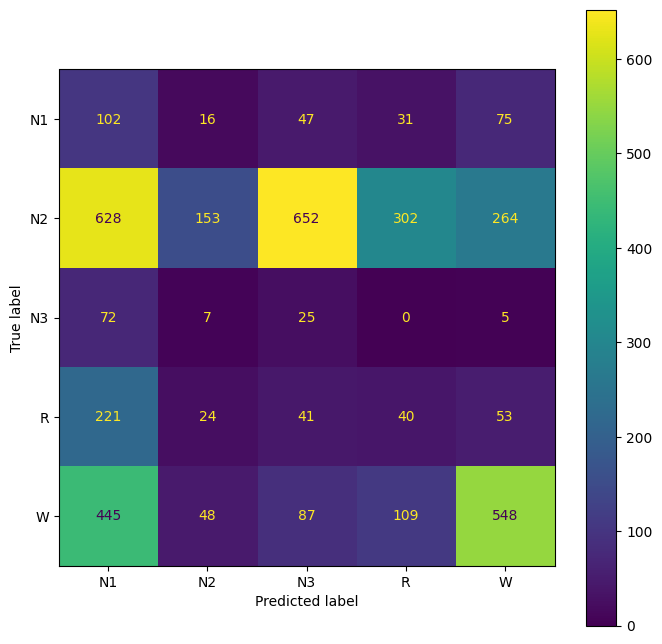

In [26]:
import matplotlib.pyplot as plt 

fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred), display_labels=["N1","N2","N3","R","W"]).plot(ax=ax)
fig.savefig(f"reports/figures/confusion_matrix_U=25_C=3_M=DCL.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

In [21]:
lb.classes_

array(['N1', 'N2', 'N3', 'R', 'W'], dtype='<U2')

In [22]:
import gc

def free_cuda():
    gc.collect()
    torch.cuda.empty_cache()


free_cuda()
del model 

In [ ]:
np.argwhere(y_test == "N2").shape